# Simple linear Regression (SLR)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Reading the data

In [5]:
from sklearn.datasets import load_diabetes

In [6]:
diabetes=load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

#### Problem Statement -> To predict disease progression one year after baseline provided 10 features
####                      In one year

In [7]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [8]:
diabetes.data

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [9]:
diabetes.target

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [12]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [21]:
data=pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
data

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [22]:
data['target']=diabetes.target

In [23]:
data

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [24]:
x=data[['bmi']]
y=data['target']

In [25]:
x

,bmi
0,0.061696
1,-0.051474
2,0.044451
3,-0.011595
4,-0.036385
...,...
437,0.019662
438,-0.015906
439,-0.015906
440,0.039062


In [26]:
y

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

### Train test split

In [27]:
from sklearn.model_selection import train_test_split

In [40]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=2)
# random_state when fixed helps us to reproduce the same result again and again

In [41]:
x_train.shape

(353, 1)

In [42]:
x_test.shape

(89, 1)

In [43]:
y_train

70      48.0
37     276.0
170     47.0
400    175.0
286     60.0
       ...  
299     83.0
22      68.0
72     202.0
15     171.0
168    268.0
Name: target, Length: 353, dtype: float64

In [44]:
y_test

212     73.0
422    233.0
67      97.0
89     111.0
390    277.0
       ...  
129    268.0
417     55.0
332    270.0
150    288.0
192     91.0
Name: target, Length: 89, dtype: float64

### Scaling(Optional)

### Model Training

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
model=LinearRegression()

In [48]:
model

LinearRegression()

In [51]:
model.fit(x_train, y_train)
# At the backend it will use gradient to give optimal coefficient

LinearRegression()

In [53]:
model.coef_ # attribute the model

array([974.48209999])

In [54]:
model.intercept_

np.float64(152.45404935855575)

In [57]:
y_pred=model.predict(x_test)
y_pred

array([155.8592353 , 228.33052685, 138.00398955, 105.44442379,
       219.92805826, 274.54410406,  94.94133806,  97.0419552 ,
       120.14874381, 210.4752811 , 153.75861815, 134.85306384,
       182.11694963, 151.65800101, 259.83978404, 121.19905238,
       190.51941821,  94.94133806, 127.50090382, 136.95368098,
       209.42497253, 222.02867541, 113.84689237, 164.26170388,
       132.75244669, 198.9218868 , 223.07898398, 128.5512124 ,
       113.84689237, 214.67651539, 235.68268686,  87.58917804,
        84.43825232, 120.14874381, 154.80892673, 161.11077816,
       171.6138639 , 168.46293818, 124.3499781 , 131.70213812,
       205.22373824, 128.5512124 , 206.27404681, 128.5512124 ,
       195.77096108, 140.1046067 , 173.71448104, 212.57589825,
       107.54504093, 159.01016102, 211.52558968, 205.22373824,
       156.90954387, 128.5512124 , 174.76478961, 122.24936096,
       114.89720095, 104.39411521, 136.95368098, 187.36849249,
       128.5512124 , 192.62003536, 144.30584099, 194.72

### Visualize the result

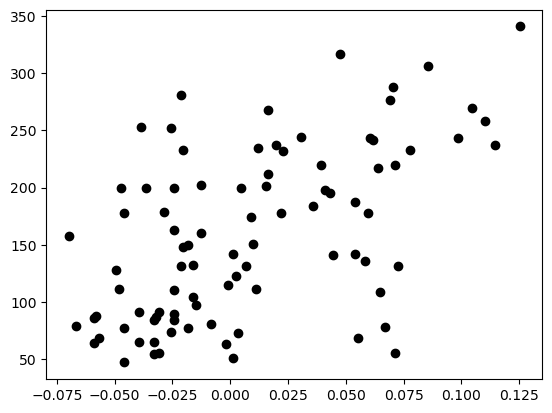

In [58]:
plt.scatter(x_test, y_test,color='black', label='Actual data')

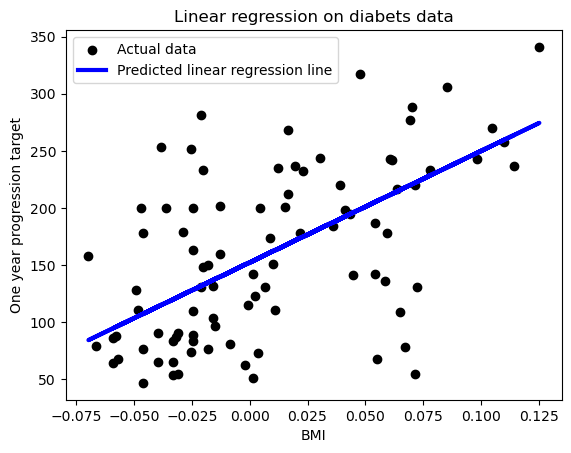

In [60]:
plt.scatter(x_test, y_test,color='black', label='Actual data')
plt.plot(x_test,y_pred, color='blue', linewidth=3, label='Predicted linear regression line')
plt.xlabel('BMI')
plt.ylabel('One year progression target')
plt.title("Linear regression on diabets data")
plt.legend()
plt.show()

### Model Evaluation

In [62]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_pred)

3898.258609540553

# Practice

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [11]:
from sklearn.linear_model import LinearRegression

In [28]:
x=[1,2,3,4,5]
y=[2.1,4.3,6.1,7.9,10.2]

In [29]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

In [30]:
model=LinearRegression()

In [31]:
model

LinearRegression()

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

[3]

array([6.1])

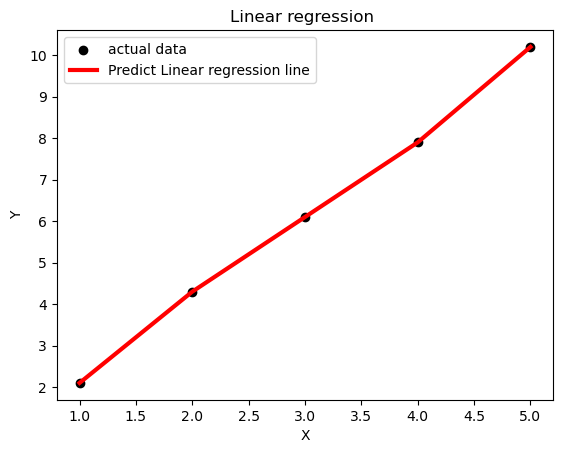

In [6]:
plt.scatter(x,y,color='black',label='actual data')
plt.plot(x,y,color='red',linewidth=3,label='Predict Linear regression line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title("Linear regression ")
plt.legend()
plt.show()

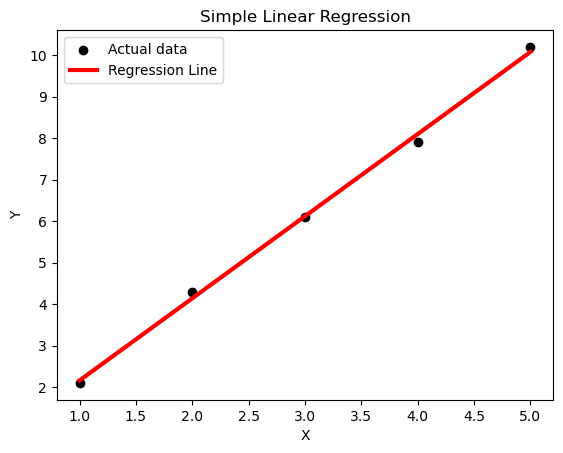

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Prepare Data
# X needs to be a 2D array for sklearn
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# 2. Fit the Model
model = LinearRegression()
model.fit(X, y)

# 3. Generate Predictions (This is what you plot as the line)
y_pred = model.predict(X)

# 4. Visualization
plt.scatter(X, y, color='black', label='Actual data')
# Use y_pred here, not the original y
plt.plot(X, y_pred, color='red', linewidth=3, label='Regression Line')

plt.xlabel('X')
plt.ylabel('Y')
plt.title("Simple Linear Regression")
plt.legend()
plt.show()